In [46]:
# Prerequisites
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import sys
from pathlib import Path

### 1. Load model output

In [47]:
# 1. Load Datasets
# Loading CMIP6 NorCPM1 data for 1pctCO2 experiment
ds_cVeg_1pct = xr.open_dataset("../CMIP6 data/NorCPM1/1ptCO2/cVeg_Lmon_NorCPM1_1pctCO2_r1i1p1f1_gn_000102-016412.nc") #Vegetation Carbon
ds_tas_1pct = xr.open_dataset("../CMIP6 data/NorCPM1/1ptCO2/tas_Amon_NorCPM1_1pctCO2_r1i1p1f1_gn_000101-016412.nc") #temperature in 1ptCO2 experiment
ds_tas_pi = xr.open_mfdataset("../CMIP6 data/NorCPM1/piControl/tas_Amon_NorCPM1_piControl_r1i1p1f1_gn_*.nc",
                               combine="by_coords",) #temperature in pre-industrial control experiment

#### check each variable

In [48]:
print(ds_tas_pi['tas'].attrs)
print(ds_tas_1pct['tas'].attrs)
print(ds_cVeg_1pct['cVeg'].attrs)

{'standard_name': 'air_temperature', 'long_name': 'Near-Surface Air Temperature', 'comment': 'near-surface (usually, 2 meter) air temperature', 'units': 'K', 'original_name': 'TREFHT', 'cell_methods': 'area: time: mean', 'cell_measures': 'area: areacella', 'history': "2019-09-14T19:23:12Z altered by CMOR: Treated scalar dimension: 'height'. 2019-09-14T19:23:13Z altered by CMOR: Converted type from 'd' to 'f'."}
{'standard_name': 'air_temperature', 'long_name': 'Near-Surface Air Temperature', 'comment': 'near-surface (usually, 2 meter) air temperature', 'units': 'K', 'original_name': 'TREFHT', 'cell_methods': 'area: time: mean', 'cell_measures': 'area: areacella', 'history': "2019-09-27T13:26:40Z altered by CMOR: Treated scalar dimension: 'height'. 2019-09-27T13:26:41Z altered by CMOR: Converted type from 'd' to 'f'."}
{'standard_name': 'vegetation_carbon_content', 'long_name': 'Carbon Mass in Vegetation', 'comment': 'Carbon mass per unit area in vegetation.', 'units': 'kg m-2', 'origin

#### check resolution of model output

In [49]:
# spatial resolution
nominal_res = ds_cVeg_1pct.attrs.get("nominal_resolution", "Not Available")
print(f"Nominal Resolution: {nominal_res}")

# time resolution
file_freq = ds_cVeg_1pct.attrs["frequency"]
print(f"Metadata Frequency: {file_freq}")

Nominal Resolution: 250 km
Metadata Frequency: mon


### 2. Convert time axis to global warming level(GWL)

In [50]:
# ==========================================
# 1. Spatial Averaging for Temperature (Global Mean)
# ==========================================

# Area-weighted global mean temperature for pre-industrial controlled simulation
weights_pi = np.cos(np.deg2rad(ds_tas_pi["lat"]))
weights_pi.name = "weights"
tas_pi_global = (
    ds_tas_pi["tas"].weighted(weights_pi).mean(dim=["lat", "lon"])
)

# Area-weighted global mean temperature for 1ptCO2 experiment
weights_1pct = np.cos(np.deg2rad(ds_tas_1pct["lat"]))
weights_1pct.name = "weights"
tas_1pct_global = (
    ds_tas_1pct["tas"].weighted(weights_1pct).mean(dim=["lat", "lon"])
)

# ==========================================
# 2. Spatial Slicing for cVeg (Keep lat and lon dimensions)
# ==========================================
# Slice the Amazon region
amazon_cVeg_1pct = ds_cVeg_1pct["cVeg"].sel(lat=slice(-20, 10), lon=slice(280, 320))

# Rename variables to prevent conflicts before merging
tas_pi_global = tas_pi_global.rename("tas_pi_global")
tas_1pct_global = tas_1pct_global.rename("tas_1pct_global")
amazon_cVeg_1pct = amazon_cVeg_1pct.rename("cVeg_1pct_amazon")

# ==========================================
# 3. Temporal Resampling to Annual Mean
# ==========================================
# convert monthly data to yearly data(one year average)
tas_pi_annual = tas_pi_global.resample(time="1YS").mean().load()
tas_1pct_annual = tas_1pct_global.resample(time="1YS").mean().load()
cVeg_annual = amazon_cVeg_1pct.resample(time="1YS").mean()

# ==========================================
# 4. Apply 10-year Smoothing to Temperatures
# ==========================================
tas_pi_smoothed = (
    tas_pi_annual.rolling(time=10, center=True, min_periods=1).mean()
)
tas_1pct_smoothed = (
    tas_1pct_annual.rolling(time=10, center=True, min_periods=1).mean()
)

# ==========================================
# 5. Align and Subtract Time-series for GWL
# ==========================================
# Merge smoothed temperatures (1D) and cVeg (3D: time, lat, lon) via inner join
# This aligns the time dimension across variables
cVeg_1pct_amazon_aligned = xr.merge(
    [tas_1pct_smoothed, tas_pi_smoothed, cVeg_annual], join="inner"
)

# Define GWL by subtracting smoothed piControl from 1pctCO2
cVeg_1pct_amazon_aligned["GWL"] = (
    cVeg_1pct_amazon_aligned["tas_1pct_global"] - cVeg_1pct_amazon_aligned["tas_pi_global"]
)

# Set GWL as a coordinate, swap the primary dimension, and sort monotonically
cVeg_1pct_amazon_aligned = (
    cVeg_1pct_amazon_aligned.set_coords("GWL")
    .swap_dims({"time": "GWL"})
    .sortby("GWL")
)

Annual average, with GWL dataset : `cVeg_1pct_amazon_aligned` : (GWL, lat, lon)

this data have annual average of Vegetation carbon content in each grid in Amazon area.

In [51]:
print(cVeg_1pct_amazon_aligned)

<xarray.Dataset> Size: 184kB
Dimensions:           (GWL: 164, lat: 16, lon: 17)
Coordinates:
    time              (GWL) object 1kB 0002-01-01 00:00:00 ... 0164-01-01 00:...
    height            float64 8B 2.0
  * lat               (lat) float64 128B -19.89 -18.0 -16.11 ... 6.632 8.526
  * lon               (lon) float64 136B 280.0 282.5 285.0 ... 315.0 317.5 320.0
  * GWL               (GWL) float64 1kB 0.01207 0.01479 0.03147 ... 4.826 4.85
Data variables:
    tas_1pct_global   (GWL) float64 1kB 285.7 285.7 285.8 ... 290.6 290.6 290.6
    tas_pi_global     (GWL) float64 1kB 285.7 285.7 285.7 ... 285.7 285.8 285.8
    cVeg_1pct_amazon  (GWL, lat, lon) float32 178kB 0.0 0.0 0.0 ... 0.0 0.0 0.0


#### Model years - GWL(Global Warming Levels)
GWL : After applying '10-year smoothing' to the annual average surface temperature time series of both simulations- 1ptCO2 and piControl-the difference between the two time series at each year

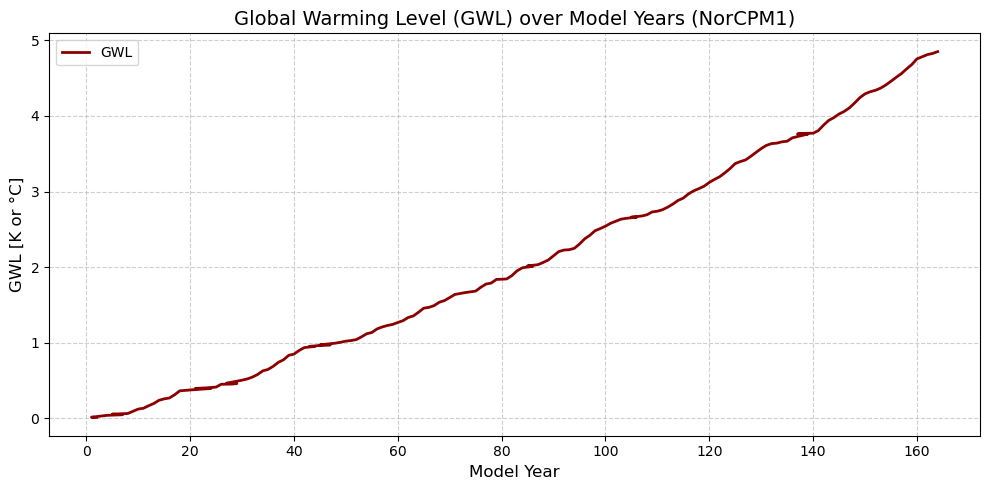

In [52]:

# ==========================================
# 1. Extract X-axis (Years) and Y-axis (GWL)
# ==========================================
# Extract the year component from the xarray time coordinate
model_years = cVeg_1pct_amazon_aligned["time"].dt.year.values
gwl_values = cVeg_1pct_amazon_aligned["GWL"].values

# ==========================================
# 2. Configure and Generate the Plot
# ==========================================
plt.figure(figsize=(10, 5))

# Plot GWL over model years
plt.plot(model_years, gwl_values, color="darkred", linewidth=2, label="GWL")

# Add chart elements
plt.title("Global Warming Level (GWL) over Model Years (NorCPM1)", fontsize=14)
plt.xlabel("Model Year", fontsize=12)
plt.ylabel("GWL [K or °C]", fontsize=12)

# Enable grid lines for better readability
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="upper left")

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

### 3. Slicing area using Amazon basin boundary

In [53]:
import geopandas as gpd
import regionmask

# ==========================================
# 1. Load Shapefile and Dissolve Geometry
# ==========================================
amazon_boundary = gpd.read_file(
    "../data/AmazonBasinLimits-master/amazon_sensulatissimo_gmm_v1.shp"
)
if (
    amazon_boundary.crs is not None
    and amazon_boundary.crs.to_string() != "EPSG:4326"
):
    amazon_boundary = amazon_boundary.to_crs(epsg=4326)

amazon_single_basin = amazon_boundary.unary_union

# ==========================================
# 2. Match Coordinates (0~360 to -180~180)
# ==========================================
# Store original [0, 360] longitude for restoration
lon_original = cVeg_1pct_amazon_aligned["lon"]

# Shift longitude values to [-180, 180] to match the shapefile CRS
lon_shifted = cVeg_1pct_amazon_aligned["lon"].where(
    cVeg_1pct_amazon_aligned["lon"] <= 180,
    cVeg_1pct_amazon_aligned["lon"] - 360,
)
cVeg_shifted = cVeg_1pct_amazon_aligned.assign_coords(lon=lon_shifted)

# ==========================================
# 3. Create 2D Mask using regionmask
# ==========================================
basin_region = regionmask.Regions([amazon_single_basin])

# Generate 2D mask matrix matching the grid points
mask = basin_region.mask(
    cVeg_shifted["lon"], cVeg_shifted["lat"], wrap_lon=False
)

# ==========================================
# 4. Apply Mask and Restore Original Coordinates
# ==========================================
# Apply the mask (Keep data where mask equals 0, set others to NaN)
masked_data_shifted = cVeg_shifted.where(mask == 0)

# Restore the original [0, 360] longitude coordinates
amazon_masked_cVeg = masked_data_shifted.assign_coords(lon=lon_original)

/var/folders/jf/2nccqn9j6_74h5ldq21d0y2r0000gn/T/ipykernel_79909/544871316.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  amazon_single_basin = amazon_boundary.unary_union


#### Extract netCDF file from preprocessing

In [54]:
# 1. Rename the variable and coordinates
amazon_masked_cVeg = amazon_masked_cVeg.rename({
    "cVeg_1pct_amazon": "cVeg"
})

# 2. Drop unnecessary temperature variables to leave only 'cVeg'
amazon_masked_cVeg = amazon_masked_cVeg.drop_vars(["tas_1pct_global", "tas_pi_global"])

# 3. Define the output file path
output_nc_path = "amazon_cVeg_for_toad.nc"

# 4. Export the clean xarray Dataset to disk
amazon_masked_cVeg.to_netcdf(output_nc_path)

Now, `amazon_masked_cVeg` is a final .nc data which have (GWL,x,y) in exact amazon basin area. If the center point of each grid in out of boundary, it read it 'NaN'

#### Plot and check data

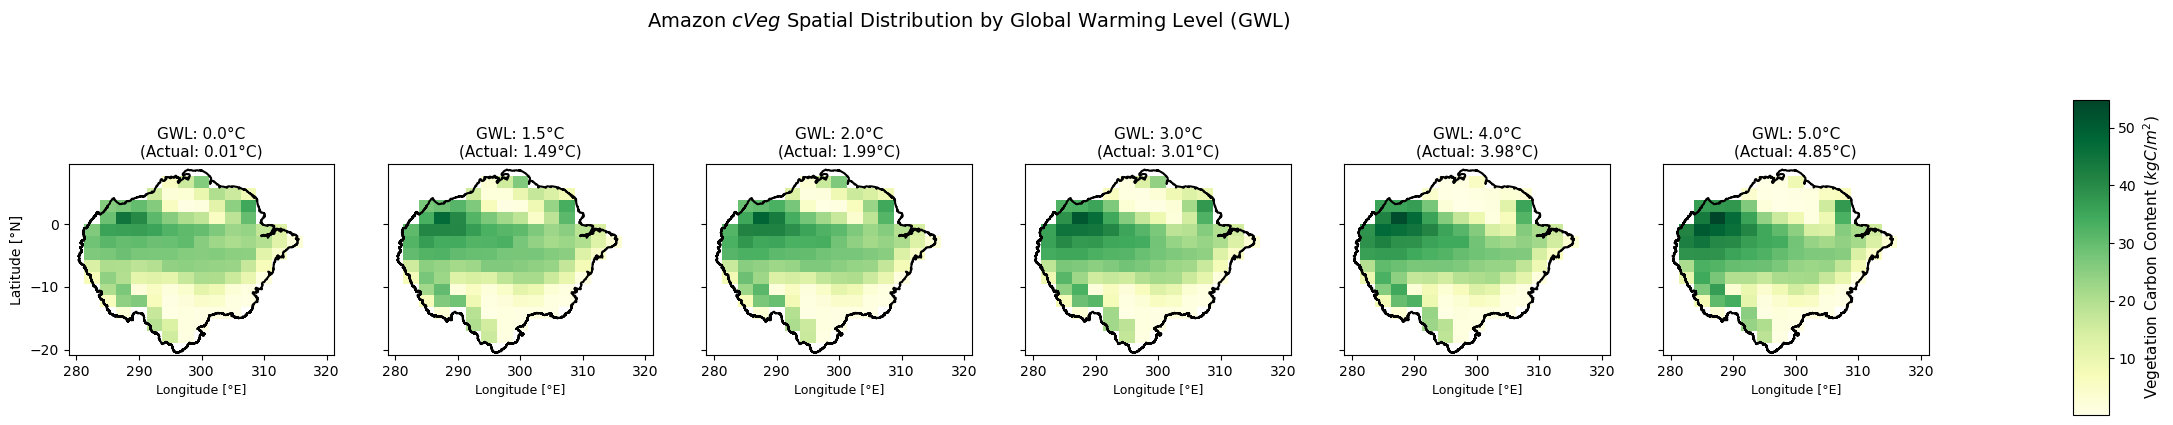

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. Extract the specific DataArray using your variable name
# ==========================================
cVeg_data_array = amazon_masked_cVeg["cVeg"]

# ==========================================
# 2. Define Target GWL Levels and Colorbar Limits
# ==========================================
target_gwls = [0.0, 1.5, 2.0, 3.0, 4.0, 5.0]

# Calculate absolute min and max values for the colorbar scale
v_min = float(cVeg_data_array.min(skipna=True))
v_max = float(cVeg_data_array.max(skipna=True))

# Initialize subplots (1 row, 6 columns)
# Width expanded to 24 to prevent horizontal compression of the 6 grids
fig, axes = plt.subplots(1, 6, figsize=(24, 4.5), sharex=True, sharey=True)

# Shift shapefile coordinates to match the [0, 360] longitude grid
amazon_boundary_360 = amazon_boundary.translate(xoff=360)

# ==========================================
# 3. Plot Spatial Maps for Each GWL Threshold
# ==========================================
for ax, target in zip(axes, target_gwls):
    # Select the 2D grid slice nearest to the target GWL value
    cVeg_slice = cVeg_data_array.sel(GWL=target, method="nearest")
    actual_gwl = float(cVeg_slice["GWL"])

    # Plot the 2D spatial grid data
    mesh = ax.pcolormesh(
        cVeg_slice["lon"],
        cVeg_slice["lat"],
        cVeg_slice.values,
        cmap="YlGn",
        vmin=v_min,
        vmax=v_max,
        shading="auto",
    )

    # Overlay the shifted Amazon basin boundary polygon
    amazon_boundary_360.plot(
        ax=ax, facecolor="none", edgecolor="black", linewidth=1.5
    )

    ax.set_title(
        f"GWL: {target}°C\n(Actual: {actual_gwl:.2f}°C)", fontsize=11
    )
    ax.set_xlabel("Longitude [°E]", fontsize=9)

axes[0].set_ylabel("Latitude [°N]", fontsize=10)

# Add unified colorbar on the right side
# Pushed further right (0.96) to accommodate the wider 6-subplot layout
cbar_ax = fig.add_axes([0.96, 0.15, 0.015, 0.7])
cbar = fig.colorbar(mesh, cax=cbar_ax)
cbar.set_label("Vegetation Carbon Content ($kgC/m^2$)", fontsize=11)

plt.suptitle(
    "Amazon $cVeg$ Spatial Distribution by Global Warming Level (GWL)",
    fontsize=14,
    y=1.05,
)
plt.show()

--- Numerical Trend Summary ---
Initial cVeg (at GWL 0.01°C): 17.4924
Final cVeg (at GWL 4.85°C): 19.8605


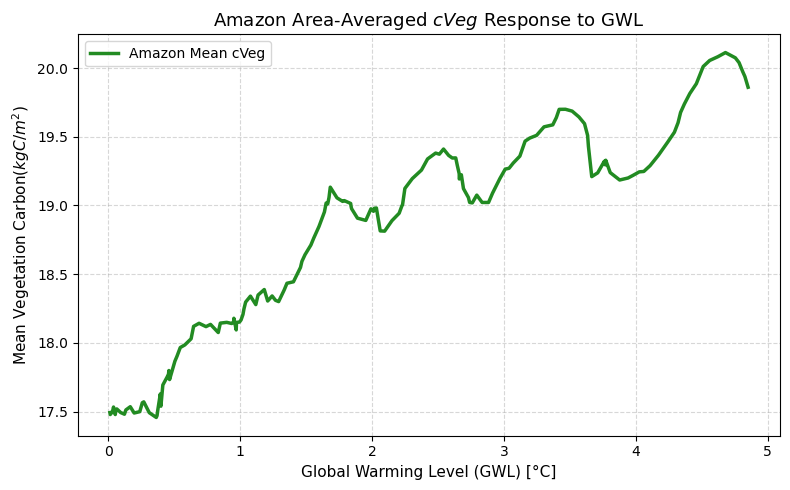

In [78]:
import matplotlib.pyplot as plt
import xarray as xr

# ==========================================
# 1. Load the Exported NetCDF File
# ==========================================
ds_check = xr.open_dataset("amazon_cVeg_for_toad.nc")

# ==========================================
# 2. Calculate Spatial Mean (Ignoring NaN values)
# ==========================================
# Dimensions were renamed to 'x' and 'y' in the previous step
amazon_spatial_mean = ds_check["cVeg"].mean(dim=["lon", "lat"], skipna=True)

# ==========================================
# 3. Print Data Summary for Numerical Verification
# ==========================================
print("--- Numerical Trend Summary ---")
print(f"Initial cVeg (at GWL {amazon_spatial_mean['GWL'].values[0]:.2f}°C): {amazon_spatial_mean.values[0]:.4f}")
print(f"Final cVeg (at GWL {amazon_spatial_mean['GWL'].values[-1]:.2f}°C): {amazon_spatial_mean.values[-1]:.4f}")

# ==========================================
# 4. Plot Mean cVeg vs GWL
# ==========================================
plt.figure(figsize=(8, 5))

# Plot the 1D line using GWL as X-axis
plt.plot(
    amazon_spatial_mean["GWL"],
    amazon_spatial_mean.values,
    color="forestgreen",
    linewidth=2.5,
    label="Amazon Mean cVeg",
)

plt.title("Amazon Area-Averaged $cVeg$ Response to GWL", fontsize=13)
plt.xlabel("Global Warming Level (GWL) [°C]", fontsize=11)
plt.ylabel("Mean Vegetation Carbon($kgC/m^2$)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

### Start TOAD

In [79]:
import sys
import os

# Get the parent directory of the 'test' folder
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Target the 'toad-main' directory which contains the actual 'toad' package folder
toad_main_path = os.path.join(parent_dir, "toad-main")

# Add the 'toad-main' path to the system path
if toad_main_path not in sys.path:
    sys.path.append(toad_main_path)

# Now Python can locate the 'toad' folder inside 'toad-main'
from toad import TOAD

td = TOAD(output_nc_path, time_dim="GWL")

### Step 1: Compute shifts


In [80]:
from toad.shifts import ASDETECT

# the test data already contains computed shifts, so let's just drop them
td.drop_shifts()

# define variable and method
td.compute_shifts(var="cVeg", method=ASDETECT(timescale=(0.05, 0.10)))
# td.compute_shifts(var="cVeg", method=ASDETECT())

# ~12 seconds

Shift detection (272 grid cells in 5 blocks):   0%|          | 0/5 [00:00<?, ?it/s]

INFO: New shifts variable cVeg_dts: min/mean/max=-1.000/-0.013/0.842 using 127 grid cells. Skipped 53.3% grid cells: 145 NaN, 0 constant.


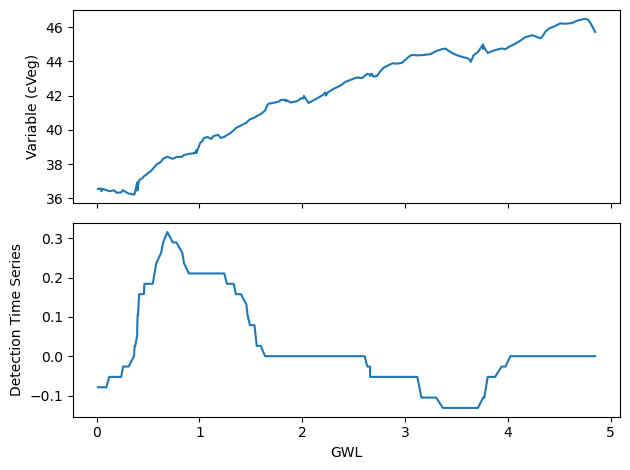

In [81]:
fig, axs = plt.subplots(2, sharex=True)
idx, idy = 4, 10

td.data.cVeg.isel(lon=idx, lat=idy).plot(ax=axs[0])
td.data.cVeg_dts.isel(lon=idx, lat=idy).plot(ax=axs[1])
axs[0].set_ylabel("Variable (cVeg)")
axs[1].set_ylabel("Detection Time Series")
axs[0].set_title("")
axs[1].set_title("")
axs[0].set_xlabel("")
fig.tight_layout()

In [82]:
from sklearn.cluster import HDBSCAN

td.data = td.data.drop_vars(td.cluster_vars)

td.compute_clusters(
    var="cVeg",  # reference your base variable, TOAD will find computed shifts for this variable
    method=HDBSCAN(min_cluster_size=3),
    time_weight=1.0,#If we use DBSCAN it won't be used
    shift_direction='negative'
)

INFO: New cluster variable cVeg_dts_cluster: Identified 4 clusters in 17 pts; Left 17.6% as noise (3 pts).



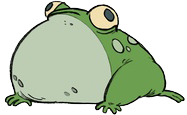

In [83]:
td

In [84]:
# You can find all method parameters used for the computation in the attributes, e.g:
td.data.cVeg_dts.attrs

{'standard_name': 'vegetation_carbon_content',
 'long_name': 'Carbon Mass in Vegetation',
 'comment': 'Carbon mass per unit area in vegetation.',
 'units': 'kg m-2',
 'original_name': 'TOTVEGC',
 'cell_methods': 'area: mean where land time: mean',
 'cell_measures': 'area: areacella',
 'history': "2019-09-27T13:48:49Z altered by CMOR: Converted type from 'd' to 'f'.",
 'time_dim': 'GWL',
 'method_name': 'ASDETECT',
 'toad_version': '1.0.7',
 'base_variable': 'cVeg',
 'variable_type': 'shift',
 'shifts_ignore_nan_warnings': 'False',
 'shifts_lmin': '5',
 'shifts_segmentation': 'two_sided',
 'shifts_timescale': '(0.05, 0.1)'}


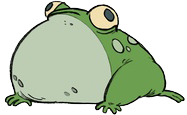

In [85]:
td

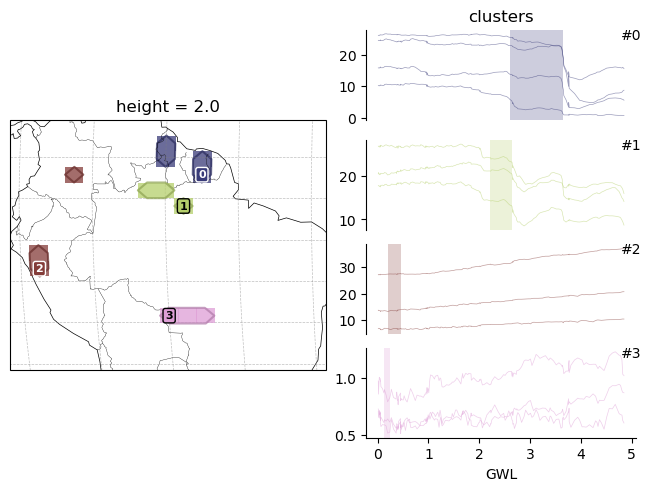

In [86]:
td.plot.overview(map_style={"projection": "global"});

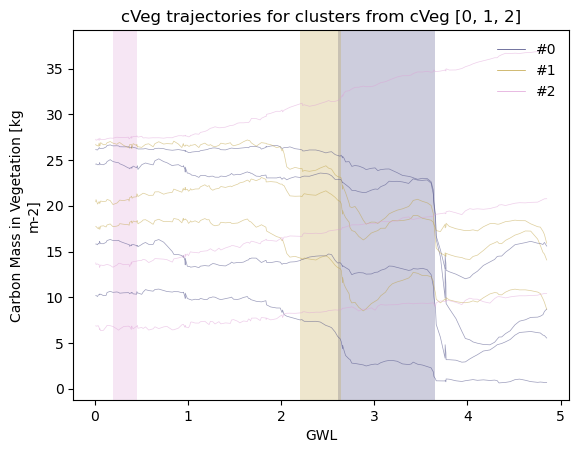

In [87]:
td.plot.timeseries(cluster_ids=[0, 1, 2]);

#### Export cluster masks & Check the cluster on the map

In [88]:
mask1 = td.get_cluster_mask_spatial("cVeg", cluster_id=0)
mask2 = td.get_cluster_mask_spatial("cVeg", cluster_id=1)
mask3 = td.get_cluster_mask_spatial("cVeg", cluster_id=2)

TypeError: Dimensions of C (16, 17) should be one smaller than X(16) and Y(17) while using shading='flat' see help(pcolormesh)

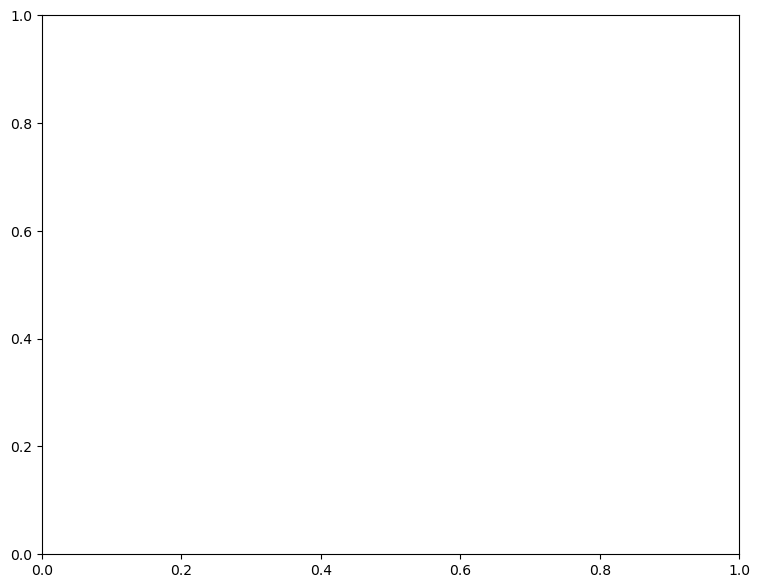

In [90]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# ==========================================
# 1. Combine Separate Masks into a Single Grid
# ==========================================
# Initialize an empty array filled with NaN
combined_mask = np.full(mask1.shape, np.nan)

# Assign distinct integer values to each cluster id
combined_mask[mask1 == 1] = 1
combined_mask[mask2 == 1] = 2
combined_mask[mask3 == 1] = 3

# ==========================================
# 2. Define Custom Discrete Colormap
# ==========================================
# Define 3 distinct colors for Cluster 0, 1, and 2
colors = ["#377eb8", "#ff7f00", "#4daf4a"]  # Blue, Orange, Green
cmap = ListedColormap(colors)

# ==========================================
# 3. Generate the Combined Plot
# ==========================================
plt.figure(figsize=(9, 7))

# Plot the categorical grid using defined vmin and vmax
mesh = plt.pcolormesh(
    mask1["lat"],
    mask1["lon"],
    combined_mask,
    cmap=cmap,
    vmin=1,
    vmax=3,
    shading="auto",
)

# Overlay the shifted Amazon basin boundary line
amazon_boundary_360 = amazon_boundary.translate(xoff=360)
amazon_boundary_360.plot(
    ax=plt.gca(), facecolor="none", edgecolor="black", linewidth=1.5
)

# ==========================================
# 4. Add Custom Legend with Cluster Numbers
# ==========================================
patch0 = mpatches.Patch(color=colors[0], label="Cluster 0")
patch1 = mpatches.Patch(color=colors[1], label="Cluster 1")
patch2 = mpatches.Patch(color=colors[2], label="Cluster 2")

plt.legend(
    handles=[patch0, patch1, patch2],
    loc="upper right",
    fontsize=11,
    frameon=True,
)

# Configure layout labels
plt.title("TOAD Spatial Clusters Map (Clusters 0, 1, 2)", fontsize=14)
plt.xlabel("Longitude [°E]", fontsize=11)
plt.ylabel("Latitude [°N]", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()